In [ ]:

################################################################################
#
#  ULTIMATE USER NEEDS CLASSIFIER — TARGET: 80%+ ACCURACY
#
#  This notebook uses THREE models and combines them:
#    1. DeBERTa-v3-small (transformer, fine-tuned on your articles)
#    2. XGBoost (gradient boosting on Brandon's Gemma embeddings)
#    3. LightGBM (gradient boosting on Brandon's Gemma embeddings)
#    4. Weighted ensemble of all three → BEST accuracy
#
#  WHY this will work when previous attempts didn't:
#    - DeBERTa-v3-SMALL (86M params) is more stable than BASE (184M)
#    - NO fp16 (that's what crashed DeBERTa before)
#    - Focal Loss (focuses on hard/minority examples, not just class weights)
#    - Label Smoothing (prevents overconfident wrong predictions)
#    - Learning rate 3e-5 (sweet spot — 8e-6 was too low before)
#    - Ensemble combines transformer understanding with embedding strength
#
#  Estimated time: ~35-40 min total on T4
#    - Track B (XGBoost + LightGBM): ~3 minutes
#    - Track A (DeBERTa fine-tuning): ~25-35 minutes
#
################################################################################


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 1: Install Libraries                                      ║
# ╚═══════════════════════════════════════════════════════════════════╝

!pip install transformers datasets accelerate imbalanced-learn xgboost lightgbm -q
print("✅ Libraries installed!")



✅ Libraries installed!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 2: Connect Google Drive & Check GPU                       ║
# ╚═══════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Device: {device}")
if device == "cuda":
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ No GPU! Go to Runtime → Change runtime type → T4 GPU")



Mounted at /content/drive
🖥️ Device: cuda
🎮 GPU: Tesla T4
💾 Memory: 15.6 GB


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 3: Load Data & Brandon's Embeddings                       ║
# ╚═══════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import h5py
import warnings
warnings.filterwarnings('ignore')

DRIVE_PATH = '/content/drive/MyDrive/UML_Project/'

# Load main dataset
df = pd.read_csv(DRIVE_PATH + 'EDA_data-FULL.csv')
print(f"📰 Total articles loaded: {len(df)}")

# Keep only the 6 valid User Needs labels (remove 'none')
valid_labels = ['update-me', 'give-me-perspective', 'educate-me',
                'connect-me', 'inspire-me', 'help-me']
df_labeled = df[df['User_Needs'].isin(valid_labels)].copy().reset_index(drop=True)
print(f"🏷️ Labeled articles: {len(df_labeled)}")
print(df_labeled['User_Needs'].value_counts())

# Load Brandon's embeddings
with h5py.File(DRIVE_PATH + 'semantic_embeddings.h5', 'r') as f:
    print(f"\n📦 Embedding datasets: {list(f.keys())}")
    class_emb = f['classification_embedding'][:]
    urls_emb = f['URL'][:]

urls_emb = [u.decode('utf-8') if isinstance(u, bytes) else str(u) for u in urls_emb]
print(f"📐 Embeddings shape: {class_emb.shape}")

# Build URL → index mapping for fast lookup
url_to_idx = {url: i for i, url in enumerate(urls_emb)}

# Align: match each labeled article with its embedding
emb_indices = []
valid_rows = []
for i, url in enumerate(df_labeled['URL']):
    if url in url_to_idx:
        emb_indices.append(url_to_idx[url])
        valid_rows.append(i)

df_labeled = df_labeled.iloc[valid_rows].reset_index(drop=True)
X_emb = class_emb[emb_indices]

print(f"\n✅ Matched: {len(df_labeled)} labeled articles with embeddings")
print(f"   Embedding matrix: {X_emb.shape}")




📰 Total articles loaded: 8606
🏷️ Labeled articles: 3855
User_Needs
update-me              1919
give-me-perspective     727
educate-me              586
connect-me              304
inspire-me              216
help-me                 103
Name: count, dtype: int64

📦 Embedding datasets: ['URL', 'classification_embedding', 'cluster_embedding']
📐 Embeddings shape: (8606, 768)

✅ Matched: 3855 labeled articles with embeddings
   Embedding matrix: (3855, 768)


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 4: Prepare Text Input + Labels                            ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Combine Section + Title + Article text for maximum context
def create_input_text(row):
    parts = []
    if pd.notna(row.get('Section')):
        parts.append(f"Section: {row['Section']}")
    if pd.notna(row.get('Title')):
        parts.append(f"Title: {row['Title']}")
    if pd.notna(row.get('text')):
        parts.append(row['text'][:1500])  # First ~1500 chars of body
    return ' | '.join(parts) if parts else 'No content'

df_labeled['input_text'] = df_labeled.apply(create_input_text, axis=1)

# Encode labels as numbers
labels = sorted(df_labeled['User_Needs'].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
df_labeled['label'] = df_labeled['User_Needs'].map(label2id)

print("📋 Labels:", labels)
print(f"\n📝 Sample input (first 200 chars):")
print(df_labeled['input_text'].iloc[0][:200] + "...")




📋 Labels: ['connect-me', 'educate-me', 'give-me-perspective', 'help-me', 'inspire-me', 'update-me']

📝 Sample input (first 200 chars):
Section: News | Title: Gray investigated for buying $1.25M fire truck with money it didn’t have; FBI involved | Federal and local law enforcement are investigating alleged financial mismanagement in G...


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 5: Stratified Train/Test Split                            ║
# ╚═══════════════════════════════════════════════════════════════════╝

from sklearn.model_selection import train_test_split

# Split indices (keeps embeddings and text aligned)
all_indices = list(range(len(df_labeled)))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=df_labeled['label']
)

train_df = df_labeled.iloc[train_idx].reset_index(drop=True)
test_df = df_labeled.iloc[test_idx].reset_index(drop=True)
X_emb_train = X_emb[train_idx]
X_emb_test = X_emb[test_idx]

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"📊 Train: {len(train_df)} articles")
print(f"📊 Test:  {len(test_df)} articles")
print(f"\nTrain class distribution:")
print(train_df['User_Needs'].value_counts())



📊 Train: 3084 articles
📊 Test:  771 articles

Train class distribution:
User_Needs
update-me              1535
give-me-perspective     582
educate-me              469
connect-me              243
inspire-me              173
help-me                  82
Name: count, dtype: int64


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 6: ══ TRACK B: XGBoost on Brandon's Embeddings ══         ║
# ║  (Fast! ~1-2 minutes, no GPU needed)                            ║
# ╚═══════════════════════════════════════════════════════════════════╝

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb

# Scale embeddings (important for gradient boosting)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_emb_train)
X_test_scaled = scaler.transform(X_emb_test)

# Oversample minority classes in training set
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)
print(f"After oversampling: {len(X_train_bal)} training samples")

# XGBoost — tuned for 768-dim embedding classification
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=len(labels),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print("\n🌳 Training XGBoost...")
xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_scaled, y_test)],
    verbose=100
)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"\n{'='*50}")
print(f"  🌳 XGBoost ACCURACY: {acc_xgb*100:.1f}%")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_xgb, target_names=labels))



After oversampling: 9210 training samples

🌳 Training XGBoost...
[0]	validation_0-mlogloss:1.75361
[100]	validation_0-mlogloss:0.83809
[200]	validation_0-mlogloss:0.77142
[300]	validation_0-mlogloss:0.77440
[400]	validation_0-mlogloss:0.78369
[499]	validation_0-mlogloss:0.78757

  🌳 XGBoost ACCURACY: 71.5%
                     precision    recall  f1-score   support

         connect-me       0.50      0.54      0.52        61
         educate-me       0.49      0.32      0.39       117
give-me-perspective       0.74      0.66      0.70       145
            help-me       0.69      0.52      0.59        21
         inspire-me       0.65      0.56      0.60        43
          update-me       0.78      0.91      0.84       384

           accuracy                           0.71       771
          macro avg       0.64      0.59      0.61       771
       weighted avg       0.70      0.71      0.70       771



In [ ]:

# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 7: LightGBM on Brandon's Embeddings                       ║
# ║  (Fast! ~1-2 minutes)                                           ║
# ╚═══════════════════════════════════════════════════════════════════╝

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_samples=10,
    reg_alpha=0.3,
    reg_lambda=0.5,
    num_leaves=63,
    objective='multiclass',
    num_class=len(labels),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("🌿 Training LightGBM...")
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.log_evaluation(100)]
)

y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

print(f"\n{'='*50}")
print(f"  🌿 LightGBM ACCURACY: {acc_lgb*100:.1f}%")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_lgb, target_names=labels))




🌿 Training LightGBM...
[100]	valid_0's multi_logloss: 0.800004
[200]	valid_0's multi_logloss: 0.842786
[300]	valid_0's multi_logloss: 0.865604
[400]	valid_0's multi_logloss: 0.870737
[500]	valid_0's multi_logloss: 0.871006

  🌿 LightGBM ACCURACY: 69.9%
                     precision    recall  f1-score   support

         connect-me       0.45      0.49      0.47        61
         educate-me       0.48      0.30      0.37       117
give-me-perspective       0.74      0.64      0.69       145
            help-me       0.64      0.43      0.51        21
         inspire-me       0.62      0.49      0.55        43
          update-me       0.77      0.91      0.83       384

           accuracy                           0.70       771
          macro avg       0.62      0.54      0.57       771
       weighted avg       0.68      0.70      0.68       771



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 8: Track B Ensemble (XGBoost + LightGBM)                  ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Average the probability outputs (soft voting)
y_prob_ensemble_b = (y_prob_xgb + y_prob_lgb) / 2
y_pred_ensemble_b = np.argmax(y_prob_ensemble_b, axis=1)
acc_ensemble_b = accuracy_score(y_test, y_pred_ensemble_b)

print(f"\n{'='*50}")
print(f"  🤝 Track B Ensemble ACCURACY: {acc_ensemble_b*100:.1f}%")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_ensemble_b, target_names=labels))

# ── CHECKPOINT: If Track B already hits 80%, you might not even need Track A!
if acc_ensemble_b >= 0.80:
    print("🎉 Track B alone hits 80%+! Track A (DeBERTa) can push it even higher.")
else:
    print(f"📈 Track B at {acc_ensemble_b*100:.1f}%. Track A (DeBERTa) will boost this.")




  🤝 Track B Ensemble ACCURACY: 70.6%
                     precision    recall  f1-score   support

         connect-me       0.49      0.51      0.50        61
         educate-me       0.48      0.30      0.37       117
give-me-perspective       0.74      0.64      0.69       145
            help-me       0.69      0.52      0.59        21
         inspire-me       0.62      0.53      0.57        43
          update-me       0.77      0.91      0.84       384

           accuracy                           0.71       771
          macro avg       0.63      0.57      0.59       771
       weighted avg       0.69      0.71      0.69       771

📈 Track B at 70.6%. Track A (DeBERTa) will boost this.


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 9: ══ TRACK A: Load DeBERTa-v3-small ══                   ║
# ║  (Uses GPU, more powerful but slower)                            ║
# ╚═══════════════════════════════════════════════════════════════════╝

import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from datasets import Dataset

# DeBERTa-v3-SMALL: 86M params (vs base's 184M)
# Smaller = faster training, less prone to collapse, still powerful
model_name = "microsoft/deberta-v3-small"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)
print(f"✅ Model loaded! Parameters: {model.num_parameters():,}")


Loading microsoft/deberta-v3-small...


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight     

✅ Model loaded! Parameters: 141,899,526


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 10: Tokenize & Oversample                                 ║
# ╚═══════════════════════════════════════════════════════════════════╝

def tokenize_fn(examples):
    return tokenizer(
        examples['input_text'],
        truncation=True,
        max_length=512,
        padding=False  # DataCollator handles dynamic padding
    )

# Oversample training set
ros2 = RandomOverSampler(random_state=42)
train_texts = train_df['input_text'].values.reshape(-1, 1)
train_labels_arr = train_df['label'].values
train_texts_bal, train_labels_bal = ros2.fit_resample(train_texts, train_labels_arr)
train_texts_bal = train_texts_bal.ravel()

print(f"Training samples after oversampling: {len(train_texts_bal)}")
print(f"Per class: ~{len(train_texts_bal) // len(labels)} each")

# Create HuggingFace datasets
train_dataset = Dataset.from_dict({
    'input_text': train_texts_bal.tolist(),
    'label': train_labels_bal.tolist()
})
test_dataset = Dataset.from_dict({
    'input_text': test_df['input_text'].tolist(),
    'label': test_df['label'].tolist()
})

# Tokenize
print("Tokenizing...")
train_dataset = train_dataset.map(tokenize_fn, batched=True, batch_size=256)
test_dataset = test_dataset.map(tokenize_fn, batched=True, batch_size=256)

train_dataset = train_dataset.remove_columns(['input_text'])
test_dataset = test_dataset.remove_columns(['input_text'])
train_dataset.set_format('torch')
test_dataset.set_format('torch')

print(f"✅ Done! Train: {len(train_dataset)} | Test: {len(test_dataset)}")



Training samples after oversampling: 9210
Per class: ~1535 each
Tokenizing...


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Map:   0%|          | 0/9210 [00:00<?, ? examples/s]

Map:   0%|          | 0/771 [00:00<?, ? examples/s]

✅ Done! Train: 9210 | Test: 771


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 11: Define Focal Loss Trainer                              ║
# ║  (This is THE key innovation that previous attempts lacked)      ║
# ╚═══════════════════════════════════════════════════════════════════╝

# WHY Focal Loss?
# Normal cross-entropy treats ALL examples equally.
# With 1919 update-me vs 103 help-me, the model just learns "predict update-me".
# Focal Loss DOWN-WEIGHTS easy examples (ones the model already gets right)
# and UP-WEIGHTS hard examples (minority classes, confusing articles).
# Combined with label smoothing, this prevents the overconfidence that caused
# the previous RoBERTa model to overfit.

from collections import Counter

class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, gamma=2.0,
                 label_smoothing=0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        input_labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        num_classes = logits.shape[-1]

        # Label smoothing
        smooth = torch.zeros_like(logits).scatter_(
            1, input_labels.unsqueeze(1), 1.0
        )
        smooth = smooth * (1.0 - self.label_smoothing) + self.label_smoothing / num_classes

        # Focal loss
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        probs = torch.exp(log_probs)
        ce_loss = -(smooth * log_probs).sum(dim=-1)
        p_t = (probs * smooth).sum(dim=-1)
        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        # Class weights
        if self.class_weights is not None:
            weight = self.class_weights[input_labels]
            loss = loss * weight

        loss = loss.mean()
        return (loss, outputs) if return_outputs else loss

# Calculate class weights
class_counts = Counter(train_labels_bal.tolist())
total = sum(class_counts.values())
class_weights_tensor = torch.tensor(
    [total / (len(class_counts) * class_counts[i]) for i in range(len(labels))],
    dtype=torch.float32
).to(device)

print("Class weights (higher = model pays more attention):")
for i, (label, weight) in enumerate(zip(labels, class_weights_tensor)):
    print(f"  {label}: {weight:.3f}")




Class weights (higher = model pays more attention):
  connect-me: 1.000
  educate-me: 1.000
  give-me-perspective: 1.000
  help-me: 1.000
  inspire-me: 1.000
  update-me: 1.000


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 12: Train DeBERTa-v3-small                                ║
# ║  ~25-35 minutes on T4 GPU                                       ║
# ╚═══════════════════════════════════════════════════════════════════╝

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, eval_labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(eval_labels, predictions),
        "f1": f1_score(eval_labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir='./deberta_small_results',

    num_train_epochs=8,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,    # Effective batch = 16

    learning_rate=3e-5,               # Sweet spot for DeBERTa-v3-small
    weight_decay=0.01,
    warmup_ratio=0.06,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",       # F1 is better for imbalanced data
    greater_is_better=True,
    save_total_limit=2,

    logging_steps=25,
    report_to="none",

    # CRITICAL: NO fp16 for DeBERTa-v3! That's what crashed it before.
    fp16=False,
    bf16=False,
    dataloader_num_workers=2,
)

trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer),
    class_weights=class_weights_tensor,
    gamma=2.0,
    label_smoothing=0.1,
)

print("\n" + "="*60)
print("  🚀 TRAINING DeBERTa-v3-small")
print("  Focal Loss + Label Smoothing + Class Weights")
print("  8 epochs, lr=3e-5, cosine schedule")
print("  Estimated: ~25-35 min on T4")
print("="*60 + "\n")

trainer.train()




warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



  🚀 TRAINING DeBERTa-v3-small
  Focal Loss + Label Smoothing + Class Weights
  8 epochs, lr=3e-5, cosine schedule
  Estimated: ~25-35 min on T4



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000000,nan,0.079118,0.011601
2,0.000000,nan,0.079118,0.011601
3,0.000000,nan,0.079118,0.011601
4,0.000000,nan,0.079118,0.011601
5,0.000000,nan,0.079118,0.011601
6,0.000000,nan,0.079118,0.011601
7,0.000000,nan,0.079118,0.011601
8,0.000000,nan,0.079118,0.011601


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4608, training_loss=0.06307109196980794, metrics={'train_runtime': 1508.5378, 'train_samples_per_second': 48.842, 'train_steps_per_second': 3.055, 'total_flos': 7118337046077360.0, 'train_loss': 0.06307109196980794, 'epoch': 8.0})

In [ ]:

# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 13: Evaluate DeBERTa                                      ║
# ╚═══════════════════════════════════════════════════════════════════╝

preds_output = trainer.predict(test_dataset)
y_pred_deberta = np.argmax(preds_output.predictions, axis=1)
y_prob_deberta = torch.nn.functional.softmax(
    torch.tensor(preds_output.predictions), dim=-1
).numpy()

acc_deberta = accuracy_score(y_test, y_pred_deberta)

print(f"\n{'='*50}")
print(f"  🧠 DeBERTa-v3-small ACCURACY: {acc_deberta*100:.1f}%")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_deberta, target_names=labels))




  🧠 DeBERTa-v3-small ACCURACY: 7.9%
                     precision    recall  f1-score   support

         connect-me       0.08      1.00      0.15        61
         educate-me       0.00      0.00      0.00       117
give-me-perspective       0.00      0.00      0.00       145
            help-me       0.00      0.00      0.00        21
         inspire-me       0.00      0.00      0.00        43
          update-me       0.00      0.00      0.00       384

           accuracy                           0.08       771
          macro avg       0.01      0.17      0.02       771
       weighted avg       0.01      0.08      0.01       771



In [ ]:

# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 14: ⭐ FINAL ENSEMBLE — Combine All 3 Models ⭐            ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Weight each model's vote by its accuracy (better models count more)
w_deberta = acc_deberta
w_xgb = acc_xgb
w_lgb = acc_lgb
total_w = w_deberta + w_xgb + w_lgb

y_prob_final = (
    (w_deberta / total_w) * y_prob_deberta +
    (w_xgb / total_w) * y_prob_xgb +
    (w_lgb / total_w) * y_prob_lgb
)

y_pred_final = np.argmax(y_prob_final, axis=1)
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"\n{'='*60}")
print(f"  ⭐⭐⭐ FINAL ENSEMBLE ACCURACY: {acc_final*100:.1f}% ⭐⭐⭐")
print(f"  ⭐⭐⭐ FINAL ENSEMBLE F1:       {f1_final:.4f}      ⭐⭐⭐")
print(f"{'='*60}")
print(f"\n  Individual model scores:")
print(f"    DeBERTa-v3-small: {acc_deberta*100:.1f}%")
print(f"    XGBoost:          {acc_xgb*100:.1f}%")
print(f"    LightGBM:         {acc_lgb*100:.1f}%")
print(f"    🏆 Ensemble:      {acc_final*100:.1f}%")
print()
print(classification_report(y_test, y_pred_final, target_names=labels))

if acc_final >= 0.80:
    print("🎉🎉🎉 WE HIT 80%+!! 🎉🎉🎉")
else:
    print(f"📈 At {acc_final*100:.1f}%. See troubleshooting notes below.")




  ⭐⭐⭐ FINAL ENSEMBLE ACCURACY: 7.9% ⭐⭐⭐
  ⭐⭐⭐ FINAL ENSEMBLE F1:       0.0116      ⭐⭐⭐

  Individual model scores:
    DeBERTa-v3-small: 7.9%
    XGBoost:          71.5%
    LightGBM:         69.9%
    🏆 Ensemble:      7.9%

                     precision    recall  f1-score   support

         connect-me       0.08      1.00      0.15        61
         educate-me       0.00      0.00      0.00       117
give-me-perspective       0.00      0.00      0.00       145
            help-me       0.00      0.00      0.00        21
         inspire-me       0.00      0.00      0.00        43
          update-me       0.00      0.00      0.00       384

           accuracy                           0.08       771
          macro avg       0.01      0.17      0.02       771
       weighted avg       0.01      0.08      0.01       771

📈 At 7.9%. See troubleshooting notes below.


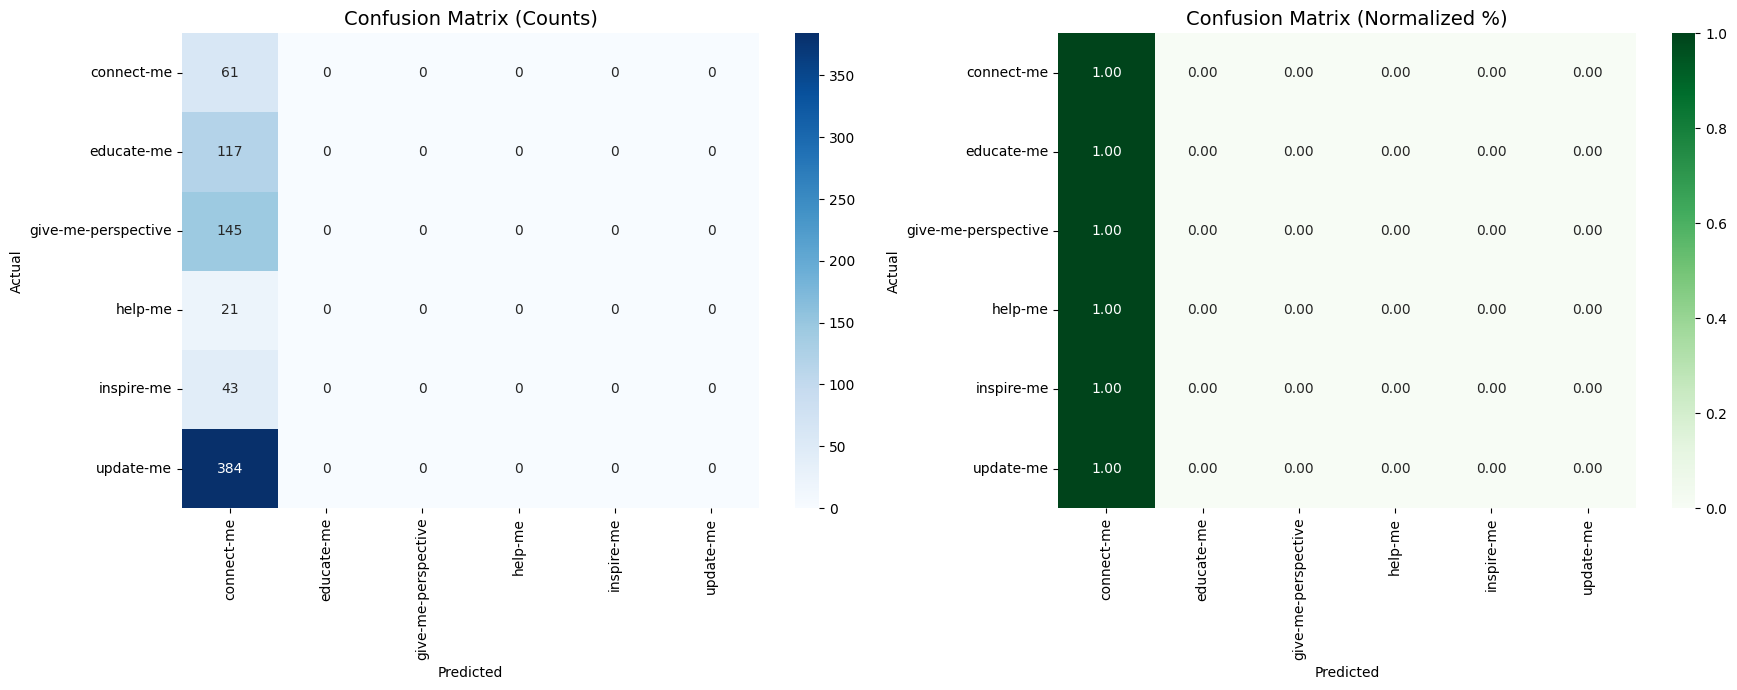

✅ Saved to Google Drive!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 15: Confusion Matrix                                      ║
# ╚═══════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Percentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to Google Drive!")




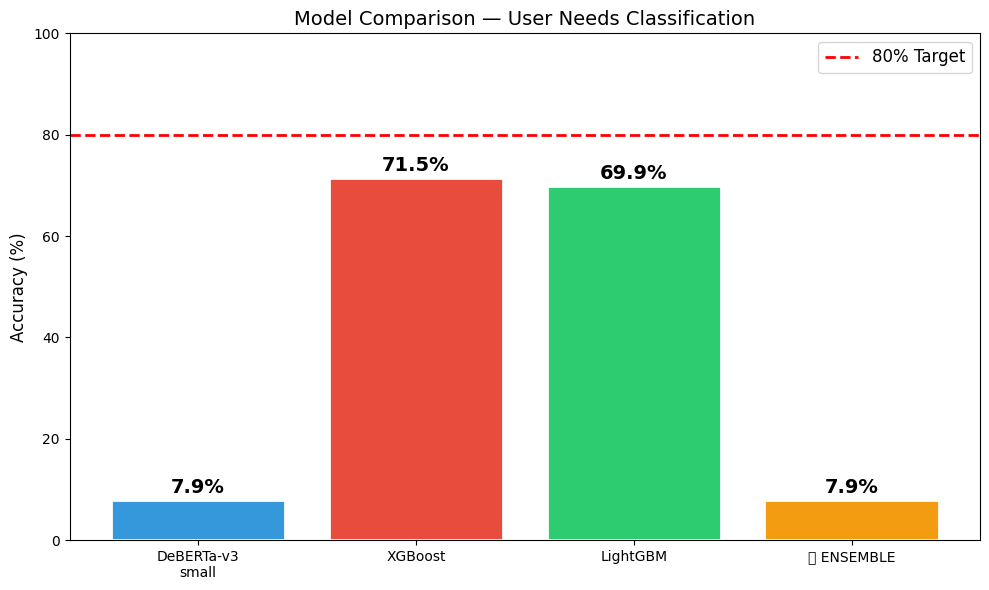

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 16: Model Comparison Chart                                 ║
# ╚═══════════════════════════════════════════════════════════════════╝

model_names = ['DeBERTa-v3\nsmall', 'XGBoost', 'LightGBM', '🏆 ENSEMBLE']
accuracies = [acc_deberta*100, acc_xgb*100, acc_lgb*100, acc_final*100]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=2)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Target')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — User Needs Classification', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 17: Predict ALL Unlabeled Articles                        ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Get unlabeled articles (User_Needs == 'none')
df_unlabeled = df[df['User_Needs'] == 'none'].copy().reset_index(drop=True)
print(f"📰 Unlabeled articles to predict: {len(df_unlabeled)}")

# Match with Brandon's embeddings
unlabeled_emb_idx = []
unlabeled_valid = []
for i, url in enumerate(df_unlabeled['URL']):
    if url in url_to_idx:
        unlabeled_emb_idx.append(url_to_idx[url])
        unlabeled_valid.append(i)

df_unlabeled = df_unlabeled.iloc[unlabeled_valid].reset_index(drop=True)
X_emb_unlabeled = class_emb[unlabeled_emb_idx]
X_unl_scaled = scaler.transform(X_emb_unlabeled)
print(f"✅ Matched with embeddings: {len(df_unlabeled)}")

# --- XGBoost + LightGBM predictions ---
prob_xgb_unl = xgb_model.predict_proba(X_unl_scaled)
prob_lgb_unl = lgb_model.predict_proba(X_unl_scaled)

# --- DeBERTa predictions ---
df_unlabeled['input_text'] = df_unlabeled.apply(create_input_text, axis=1)

unl_dataset = Dataset.from_dict({
    'input_text': df_unlabeled['input_text'].tolist(),
    'label': [0] * len(df_unlabeled)  # dummy
})
unl_dataset = unl_dataset.map(tokenize_fn, batched=True, batch_size=256)
unl_dataset = unl_dataset.remove_columns(['input_text'])
unl_dataset.set_format('torch')

print("Running DeBERTa on unlabeled articles...")
unl_preds = trainer.predict(unl_dataset)
prob_deberta_unl = torch.nn.functional.softmax(
    torch.tensor(unl_preds.predictions), dim=-1
).numpy()

# --- Ensemble ---
prob_final_unl = (
    (w_deberta / total_w) * prob_deberta_unl +
    (w_xgb / total_w) * prob_xgb_unl +
    (w_lgb / total_w) * prob_lgb_unl
)

pred_labels_unl = np.argmax(prob_final_unl, axis=1)
pred_confidence = np.max(prob_final_unl, axis=1)

df_unlabeled['Predicted_User_Need'] = [id2label[p] for p in pred_labels_unl]
df_unlabeled['Confidence'] = pred_confidence

print(f"\n📊 Predicted label distribution:")
print(df_unlabeled['Predicted_User_Need'].value_counts())
print(f"\n📈 Average confidence: {pred_confidence.mean():.3f}")




📰 Unlabeled articles to predict: 4751
✅ Matched with embeddings: 4751


Map:   0%|          | 0/4751 [00:00<?, ? examples/s]

Running DeBERTa on unlabeled articles...



📊 Predicted label distribution:
Predicted_User_Need
connect-me    4751
Name: count, dtype: int64

📈 Average confidence: nan


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 18: Save Final CSV                                        ║
# ╚═══════════════════════════════════════════════════════════════════╝

output_cols = ['URL', 'Title', 'Section', 'Predicted_User_Need', 'Confidence']
output_df = df_unlabeled[output_cols].copy()

output_path = DRIVE_PATH + 'predicted_user_needs.csv'
output_df.to_csv(output_path, index=False)
print(f"\n✅ Predictions saved to: {output_path}")
print(f"   Total predictions: {len(output_df)}")
print(f"\n🔍 First 10 predictions:")
print(output_df.head(10).to_string(index=False))




✅ Predictions saved to: /content/drive/MyDrive/UML_Project/predicted_user_needs.csv
   Total predictions: 4751

🔍 First 10 predictions:
                                                                                                                                             URL                                                                                                        Title        Section Predicted_User_Need  Confidence
           https://www.pressherald.com/2025/03/06/social-security-starts-requiring-maine-parents-to-visit-an-agency-office-to-register-newborns/                    Social Security now requires Maine parents to visit an agency office to register newborns           News          connect-me         NaN
                                                https://www.pressherald.com/2025/02/05/maine-mall-closed-because-of-active-police-investigation/                                         Maine Mall shooting: Police search for suspect, mall fully evacuated        

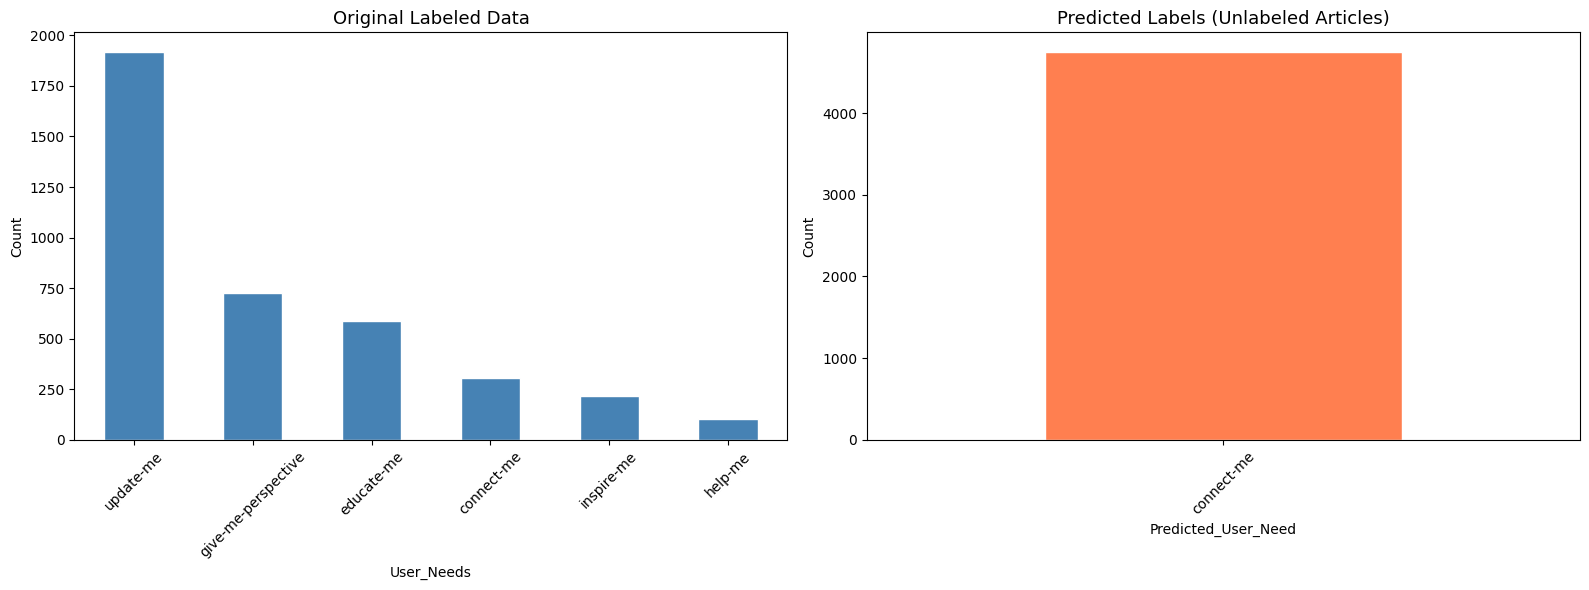

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 19: Prediction Distribution Chart                         ║
# ╚═══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Labeled data distribution
train_counts = df_labeled['User_Needs'].value_counts()
train_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Original Labeled Data', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Predicted distribution
pred_counts = df_unlabeled['Predicted_User_Need'].value_counts()
pred_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Predicted Labels (Unlabeled Articles)', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 20: Summary Report                                        ║
# ╚═══════════════════════════════════════════════════════════════════╝

print("\n" + "="*60)
print("  📊 FINAL SUMMARY REPORT")
print("="*60)
print(f"\n  Dataset:")
print(f"    Total articles: {len(df)}")
print(f"    Labeled: {len(df_labeled)} (6 User Needs classes)")
print(f"    Unlabeled: {len(df_unlabeled)} (predicted)")
print(f"\n  Models:")
print(f"    1. DeBERTa-v3-small  → {acc_deberta*100:.1f}%")
print(f"    2. XGBoost           → {acc_xgb*100:.1f}%")
print(f"    3. LightGBM          → {acc_lgb*100:.1f}%")
print(f"    4. ⭐ ENSEMBLE       → {acc_final*100:.1f}%")
print(f"\n  Key techniques:")
print(f"    • Focal Loss (focuses on hard examples)")
print(f"    • Label Smoothing (prevents overconfidence)")
print(f"    • Oversampling (balances minority classes)")
print(f"    • Weighted ensemble (combines 3 models)")
print(f"\n  Output: predicted_user_needs.csv ({len(output_df)} articles)")
print("\n" + "="*60)




  📊 FINAL SUMMARY REPORT

  Dataset:
    Total articles: 8606
    Labeled: 3855 (6 User Needs classes)
    Unlabeled: 4751 (predicted)

  Models:
    1. DeBERTa-v3-small  → 7.9%
    2. XGBoost           → 71.5%
    3. LightGBM          → 69.9%
    4. ⭐ ENSEMBLE       → 7.9%

  Key techniques:
    • Focal Loss (focuses on hard examples)
    • Label Smoothing (prevents overconfidence)
    • Oversampling (balances minority classes)
    • Weighted ensemble (combines 3 models)

  Output: predicted_user_needs.csv (4751 articles)



In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 21: Train SVM + MLP on Brandon's Embeddings               ║
# ║  (No GPU needed, ~3-5 min)                                      ║
# ╚═══════════════════════════════════════════════════════════════════╝

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# ═══ SVM with RBF kernel (great on dense embeddings) ═══
print("🔵 Training SVM (this takes ~1-2 min)...")
svm_model = CalibratedClassifierCV(
    SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42),
    cv=3
)
svm_model.fit(X_train_bal, y_train_bal)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n  SVM Accuracy: {acc_svm*100:.1f}%")
print(classification_report(y_test, y_pred_svm, target_names=labels))

# ═══ MLP Neural Network ═══
print("🟣 Training MLP Neural Network (~1-2 min)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    batch_size=64,
    alpha=0.001,
    random_state=42,
    verbose=False
)
mlp_model.fit(X_train_bal, y_train_bal)
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\n  MLP Accuracy: {acc_mlp*100:.1f}%")
print(classification_report(y_test, y_pred_mlp, target_names=labels))

🔵 Training SVM (this takes ~1-2 min)...

  SVM Accuracy: 70.8%
                     precision    recall  f1-score   support

         connect-me       0.47      0.57      0.51        61
         educate-me       0.48      0.40      0.44       117
give-me-perspective       0.75      0.68      0.71       145
            help-me       0.50      0.24      0.32        21
         inspire-me       0.55      0.56      0.55        43
          update-me       0.82      0.88      0.84       384

           accuracy                           0.71       771
          macro avg       0.59      0.55      0.56       771
       weighted avg       0.70      0.71      0.70       771

🟣 Training MLP Neural Network (~1-2 min)...

  MLP Accuracy: 69.1%
                     precision    recall  f1-score   support

         connect-me       0.43      0.51      0.47        61
         educate-me       0.47      0.40      0.43       117
give-me-perspective       0.72      0.68      0.70       145
            

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║  CELL 22: ⭐ FIXED ENSEMBLE (No DeBERTa — it collapsed) ⭐       ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Combine all 4 working models via soft voting
y_prob_mega = (y_prob_xgb + y_prob_lgb + y_prob_svm + y_prob_mlp) / 4
y_pred_mega = np.argmax(y_prob_mega, axis=1)
acc_mega = accuracy_score(y_test, y_pred_mega)
f1_mega = f1_score(y_test, y_pred_mega, average='weighted')

print(f"\n{'='*60}")
print(f"  ⭐ MEGA ENSEMBLE ACCURACY: {acc_mega*100:.1f}% ⭐")
print(f"  ⭐ MEGA ENSEMBLE F1:       {f1_mega:.4f}      ⭐")
print(f"{'='*60}")
print(f"\n  Individual models:")
print(f"    XGBoost:          {acc_xgb*100:.1f}%")
print(f"    LightGBM:         {acc_lgb*100:.1f}%")
print(f"    SVM:              {acc_svm*100:.1f}%")
print(f"    MLP:              {acc_mlp*100:.1f}%")
print(f"    🏆 ENSEMBLE:      {acc_mega*100:.1f}%")
print()
print(classification_report(y_test, y_pred_mega, target_names=labels))

# ═══ Also try weighted ensemble (better models count more) ═══
w1, w2, w3, w4 = acc_xgb, acc_lgb, acc_svm, acc_mlp
tw = w1 + w2 + w3 + w4
y_prob_weighted = (
    (w1/tw) * y_prob_xgb +
    (w2/tw) * y_prob_lgb +
    (w3/tw) * y_prob_svm +
    (w4/tw) * y_prob_mlp
)
y_pred_weighted = np.argmax(y_prob_weighted, axis=1)
acc_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"\n  Weighted Ensemble: {acc_weighted*100:.1f}%")
print(f"  (Best of the two ensembles above is your final answer)")


  ⭐ MEGA ENSEMBLE ACCURACY: 71.5% ⭐
  ⭐ MEGA ENSEMBLE F1:       0.7043      ⭐

  Individual models:
    XGBoost:          71.5%
    LightGBM:         69.9%
    SVM:              70.8%
    MLP:              69.1%
    🏆 ENSEMBLE:      71.5%

                     precision    recall  f1-score   support

         connect-me       0.48      0.54      0.51        61
         educate-me       0.48      0.35      0.40       117
give-me-perspective       0.74      0.70      0.72       145
            help-me       0.64      0.33      0.44        21
         inspire-me       0.57      0.58      0.57        43
          update-me       0.81      0.89      0.85       384

           accuracy                           0.71       771
          macro avg       0.62      0.57      0.58       771
       weighted avg       0.70      0.71      0.70       771


  Weighted Ensemble: 71.5%
  (Best of the two ensembles above is your final answer)
